### ETL: Preparación de los datos

Cargamos las librerias necesarias

In [1]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ( 
    train_test_split,
    StratifiedKFold,
    cross_validate
)
import hashlib
import joblib
import seaborn as sns
sns.set_theme(style="white")

## 1. Localización de los datos procesados

En esta etapa se utilizarán los archivos de `d02_processed_data` que fueron revisados durante el análisis exploratorio. Como el inventario completo ya se presentó en el EDA, no se volverá a mostrar la tabla con todos los nombres.

Solamente se verificará que la carpeta exista y que contenga los 32 archivos esperados: dos archivos para cada una de las 16 actividades de entrenamiento. Esta comprobación permite detectar rápidamente una ruta incorrecta o la ausencia de algún archivo antes de continuar con el procesamiento.

##### Reconstrucción del archivo `014_1.npy`

El archivo procesado `014_1.npy` presentó corrupción binaria, por lo que fue reconstruido a partir de su versión raw mediante un filtro de media móvil y normalización a media cero. El procedimiento se validó numéricamente con seis archivos oficiales y el resultado reconstruido se encuentra en `Reconstrucción de archivo corrupto/resultados_reconstruccion/014_1.npy`.

In [2]:
# Ruta de la carpeta con los datos procesados
RUTA_DATOS = Path("../Rehab_exercise/d02_processed_data")

# Comprobamos que la carpeta exista.
if not RUTA_DATOS.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta: {RUTA_DATOS.resolve()}"
    )

# Buscamos los archivos NumPy disponibles.
archivos_npy = sorted(RUTA_DATOS.glob("*.npy"))

# Verificamos que exista la cantidad esperada:
# 16 actividades × 2 archivos por actividad = 32 archivos.
if len(archivos_npy) != 32:
    raise ValueError(
        f"Se esperaban 32 archivos .npy, pero se encontraron "
        f"{len(archivos_npy)}."
    )

print("Carpeta localizada correctamente.")
print("Cantidad de archivos encontrados:", len(archivos_npy))

Carpeta localizada correctamente.
Cantidad de archivos encontrados: 32


### Interpretación

La carpeta de datos procesados fue localizada correctamente y contiene los 32 archivos esperados. Esta cantidad corresponde a las 16 actividades de entrenamiento, cada una con dos archivos asociados a los diferentes grupos de sensores.

El inventario detallado no se muestra nuevamente porque ya fue revisado durante el análisis exploratorio inicial. En los siguientes pasos se comprobará el contenido de los archivos, ya que su presencia en la carpeta no garantiza que todos puedan cargarse correctamente.

## 2. Carga de los archivos procesados

En este paso se cargarán los 32 archivos correspondientes a las 16 actividades y los dos grupos de sensores. El archivo `014_1.npy` dañado fue sustituido previamente por su versión reconstruida y validada, por lo que todos los archivos pueden cargarse desde `d02_processed_data`.

Aunque las dimensiones generales ya fueron revisadas en el EDA, se realizará una validación automática para asegurar que cada arreglo conserve la estructura esperada de muestras, 880 puntos temporales y 6 canales antes de continuar con la unión de sensores.

In [3]:
# ---------------------------------------------------------
# Carga y validación de los 32 archivos procesados
# ---------------------------------------------------------

datos_cargados = {}

for archivo in archivos_npy:

    # Cargamos el archivo como un arreglo numérico.
    datos = np.load(
        archivo,
        allow_pickle=False
    )

    # Verificamos la estructura esperada:
    # (muestras, 880 puntos temporales, 6 canales).
    estructura_valida = (
        datos.ndim == 3
        and datos.shape[1] == 880
        and datos.shape[2] == 6
    )

    if not estructura_valida:
        raise ValueError(
            f"El archivo {archivo.name} tiene dimensiones "
            f"inesperadas: {datos.shape}"
        )

    # Guardamos cada arreglo utilizando su nombre.
    datos_cargados[archivo.name] = datos


# ---------------------------------------------------------
# Resumen
# ---------------------------------------------------------

print("Archivos cargados correctamente:", len(datos_cargados))

print(
    "Shape de 014_1 reconstruido:",
    datos_cargados["014_1.npy"].shape
)

print(
    "Shape de 014_2 oficial:",
    datos_cargados["014_2.npy"].shape
)

Archivos cargados correctamente: 32
Shape de 014_1 reconstruido: (359, 880, 6)
Shape de 014_2 oficial: (359, 880, 6)


### Interpretación

Los 32 archivos se cargaron correctamente y presentan la estructura esperada. El archivo `014_1.npy` reconstruido contiene 359 muestras, 880 puntos temporales y 6 canales, por lo que es compatible con `014_2.npy` y puede utilizarse en las siguientes etapas del ETL.

## 3. Unión de los grupos de sensores y asignación de etiquetas

Cada actividad cuenta con dos archivos que representan diferentes grupos de sensores. Antes de unirlos, se comprobará que ambos tengan la misma cantidad de muestras y los mismos 880 puntos temporales.

Después, los seis canales de `_1` y los seis canales de `_2` se concatenarán para formar muestras con 12 canales. A cada muestra se le asignará la etiqueta de la actividad correspondiente y un identificador técnico para poder rastrearla durante la limpieza y separación de los datos.

In [4]:
# ---------------------------------------------------------
# Nombres de los 12 canales
# ---------------------------------------------------------

canales = [
    "pitch1",
    "yaw1",
    "roll1",
    "pitch2",
    "yaw2",
    "roll2",
    "f1",
    "f2",
    "f3",
    "f4",
    "f5",
    "pitch3"
]


# ---------------------------------------------------------
# Listas para construir el conjunto completo
# ---------------------------------------------------------

lista_datos = []
lista_etiquetas = []
lista_metadatos = []


# ---------------------------------------------------------
# Unión de los sensores para cada actividad
# ---------------------------------------------------------

for numero_actividad in range(16):

    # Convertimos el número al formato del nombre
    # de los archivos: 0 -> "000", 1 -> "001".
    actividad = f"{numero_actividad:03d}"

    nombre_archivo_1 = f"{actividad}_1.npy"
    nombre_archivo_2 = f"{actividad}_2.npy"

    # Recuperamos los dos arreglos de la actividad.
    datos_sensor_1 = datos_cargados[nombre_archivo_1]
    datos_sensor_2 = datos_cargados[nombre_archivo_2]

    # Comprobamos que ambos grupos tengan la misma
    # cantidad de muestras y puntos temporales.
    if datos_sensor_1.shape[:2] != datos_sensor_2.shape[:2]:
        raise ValueError(
            f"Los archivos de la actividad {actividad} "
            f"no tienen estructuras compatibles: "
            f"{datos_sensor_1.shape} y {datos_sensor_2.shape}"
        )

    # Unimos los seis canales de cada archivo.
    #
    # (muestras, 880, 6) + (muestras, 880, 6)
    #                  ↓
    #          (muestras, 880, 12)
    datos_actividad = np.concatenate(
        [datos_sensor_1, datos_sensor_2],
        axis=2
    )

    numero_muestras = datos_actividad.shape[0]

    # Guardamos los datos combinados de la actividad.
    lista_datos.append(datos_actividad)

    # Creamos una etiqueta para cada muestra.
    etiquetas_actividad = np.full(
        numero_muestras,
        actividad
    )

    lista_etiquetas.append(etiquetas_actividad)

    # Creamos un identificador técnico para rastrear
    # cada muestra durante la limpieza.
    for indice_muestra in range(numero_muestras):

        lista_metadatos.append({
            "sample_id": f"{actividad}_{indice_muestra:04d}",
            "actividad": actividad,
            "indice_original": indice_muestra
        })


# ---------------------------------------------------------
# Unión de las 16 actividades
# ---------------------------------------------------------

datos_iniciales = np.concatenate(
    lista_datos,
    axis=0
)

etiquetas_iniciales = np.concatenate(
    lista_etiquetas
)

metadatos_iniciales = pd.DataFrame(
    lista_metadatos
)


# ---------------------------------------------------------
# Comprobación de las cantidades
# ---------------------------------------------------------

if not (
    datos_iniciales.shape[0]
    == etiquetas_iniciales.shape[0]
    == len(metadatos_iniciales)
):
    raise ValueError(
        "La cantidad de datos, etiquetas y metadatos no coincide."
    )


# ---------------------------------------------------------
# Resumen
# ---------------------------------------------------------

print(
    "Dimensiones de los datos:",
    datos_iniciales.shape
)

print(
    "Cantidad de etiquetas:",
    etiquetas_iniciales.shape
)

print(
    "Dimensiones de los metadatos:",
    metadatos_iniciales.shape
)

print(
    "Cantidad de actividades:",
    len(np.unique(etiquetas_iniciales))
)

print(
    "Cantidad de canales:",
    len(canales)
)

Dimensiones de los datos: (4616, 880, 12)
Cantidad de etiquetas: (4616,)
Dimensiones de los metadatos: (4616, 3)
Cantidad de actividades: 16
Cantidad de canales: 12


### Interpretación

Los archivos de los dos grupos de sensores se unieron correctamente para las 16 actividades. Posteriormente, las muestras de todas las actividades se concatenaron en un solo conjunto.

Los resultados representan lo siguiente:

- **Datos `(4616, 880, 12)`:** el conjunto contiene 4,616 muestras. Cada muestra tiene 880 puntos temporales y 12 canales, obtenidos al unir los seis canales de `_1` con los seis canales de `_2`.

- **Etiquetas `(4616,)`:** existe una etiqueta por cada muestra. La etiqueta indica la actividad a la que pertenece, desde `000` hasta `015`.

- **Metadatos `(4616, 3)`:** existe una fila de información de seguimiento por cada muestra. Sus columnas son `sample_id`, `actividad` e `indice_original`.

- **16 actividades:** se conservaron todas las clases de entrenamiento.

- **12 canales:** se utilizará la información de ambos grupos de sensores.

Los metadatos no son variables que se entregarán al modelo. Se crearon únicamente para identificar y rastrear cada muestra durante la limpieza, por ejemplo, para saber qué actividad e índice original corresponde a una señal en cero o duplicada.

El `sample_id` es un identificador técnico creado durante el ETL y no representa al paciente ni a la sesión, porque los archivos procesados no proporcionan esa información.

## 4. Eliminación de muestras completamente en cero

Durante el EDA se identificaron muestras completamente en cero. Al revisar conjuntamente los dos grupos de sensores, se comprobó que 68 muestras tienen los 12 canales en cero, por lo que no contienen información sobre el movimiento y serán eliminadas antes de dividir los datos.

También existen seis muestras en las que únicamente el grupo `_1` está en cero, pero el grupo `_2` conserva información. Estas muestras se mantendrán por el momento. La limpieza no considera como inválidas las señales que solamente tienen ceros al final, ya que pueden corresponder al padding utilizado para completar los 880 puntos.

In [5]:
# ---------------------------------------------------------
# Identificación de ceros por grupo de sensores
# ---------------------------------------------------------

# Primeros seis canales: archivo _1.
cero_grupo_1 = np.all(
    datos_iniciales[:, :, :6] == 0,
    axis=(1, 2)
)

# Últimos seis canales: archivo _2.
cero_grupo_2 = np.all(
    datos_iniciales[:, :, 6:] == 0,
    axis=(1, 2)
)

# Muestras sin información en ninguno de los 12 canales.
cero_en_ambos = (
    cero_grupo_1
    & cero_grupo_2
)

# Muestras donde solamente uno de los grupos está en cero.
cero_solo_grupo_1 = (
    cero_grupo_1
    & ~cero_grupo_2
)

cero_solo_grupo_2 = (
    cero_grupo_2
    & ~cero_grupo_1
)


# ---------------------------------------------------------
# Registro del resultado en los metadatos
# ---------------------------------------------------------

metadatos_calidad = metadatos_iniciales.copy()

metadatos_calidad["cero_grupo_1"] = cero_grupo_1
metadatos_calidad["cero_grupo_2"] = cero_grupo_2
metadatos_calidad["cero_en_ambos"] = cero_en_ambos


# Guardamos por separado los metadatos de las muestras
# que serán eliminadas, para conservar evidencia.
muestras_cero_eliminadas = (
    metadatos_calidad[cero_en_ambos]
    .copy()
)


# ---------------------------------------------------------
# Resumen antes de la limpieza
# ---------------------------------------------------------

print(
    "Muestras completamente en cero en _1:",
    cero_grupo_1.sum()
)

print(
    "Muestras completamente en cero en _2:",
    cero_grupo_2.sum()
)

print(
    "Muestras en cero en ambos grupos:",
    cero_en_ambos.sum()
)

print(
    "Muestras en cero solamente en _1:",
    cero_solo_grupo_1.sum()
)

print(
    "Muestras en cero solamente en _2:",
    cero_solo_grupo_2.sum()
)


# ---------------------------------------------------------
# Eliminación de muestras sin información
# ---------------------------------------------------------

# La máscara será True para las muestras que se conservarán.
mascara_con_informacion = ~cero_en_ambos

datos_sin_ceros = datos_iniciales[
    mascara_con_informacion
]

etiquetas_sin_ceros = etiquetas_iniciales[
    mascara_con_informacion
]

metadatos_sin_ceros = (
    metadatos_calidad[mascara_con_informacion]
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Comprobación de la limpieza
# ---------------------------------------------------------

print("\nMuestras antes de la limpieza:")
print(datos_iniciales.shape[0])

print("\nMuestras eliminadas:")
print(cero_en_ambos.sum())

print("\nMuestras después de la limpieza:")
print(datos_sin_ceros.shape[0])

print("\nDimensiones después de la limpieza:")
print(datos_sin_ceros.shape)

Muestras completamente en cero en _1: 74
Muestras completamente en cero en _2: 68
Muestras en cero en ambos grupos: 68
Muestras en cero solamente en _1: 6
Muestras en cero solamente en _2: 0

Muestras antes de la limpieza:
4616

Muestras eliminadas:
68

Muestras después de la limpieza:
4548

Dimensiones después de la limpieza:
(4548, 880, 12)


### Interpretación

Se eliminaron 68 muestras cuyos 880 puntos y 12 canales estaban completamente en cero, debido a que no contenían información del movimiento. Después de la limpieza quedaron 4,548 muestras válidas.

Se conservaron seis muestras en las que solamente el grupo `_1` estaba en cero, ya que el grupo `_2` todavía contenía información. Esta decisión podrá revisarse posteriormente mediante una comparación del desempeño del modelo, pero evita eliminar datos que aún pueden ser útiles.

## 5. Identificación de muestras duplicadas

Durante el EDA se encontraron duplicados al analizar los archivos por separado. En esta etapa se revisarán nuevamente después de unir ambos grupos de sensores y eliminar las muestras completamente en cero.

Dos muestras se considerarán duplicadas solamente si coinciden exactamente en sus 880 puntos y 12 canales. También se verificará si las muestras idénticas tienen la misma actividad o si existe un conflicto de etiquetas.

En este paso únicamente se identificarán y resumirán los duplicados. La eliminación se realizará después de revisar los resultados.

In [6]:
# ---------------------------------------------------------
# Creación de una firma para cada muestra
# ---------------------------------------------------------

firmas_muestras = []

for muestra in datos_sin_ceros:

    # Convertimos la muestra completa de 880 × 12 en bytes.
    muestra_bytes = np.ascontiguousarray(
        muestra
    ).tobytes()

    # Creamos una firma única a partir de todos sus valores.
    firma = hashlib.sha256(
        muestra_bytes
    ).hexdigest()

    firmas_muestras.append(firma)


# ---------------------------------------------------------
# Incorporación de las firmas a los metadatos
# ---------------------------------------------------------

metadatos_duplicados = metadatos_sin_ceros.copy()

metadatos_duplicados["firma"] = firmas_muestras


# Una muestra se marca como duplicada si su firma aparece
# más de una vez en el conjunto.
metadatos_duplicados["es_duplicada"] = (
    metadatos_duplicados["firma"]
    .duplicated(keep=False)
)

# Esta columna marca solamente las copias posteriores.
# La primera aparición de cada muestra se considera
# la copia que podría conservarse.
metadatos_duplicados["copia_adicional"] = (
    metadatos_duplicados["firma"]
    .duplicated(keep="first")
)


# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------

cantidad_muestras_duplicadas = (
    metadatos_duplicados["es_duplicada"].sum()
)

cantidad_copias_adicionales = (
    metadatos_duplicados["copia_adicional"].sum()
)

cantidad_grupos_duplicados = (
    metadatos_duplicados.loc[
        metadatos_duplicados["es_duplicada"],
        "firma"
    ]
    .nunique()
)

print(
    "Muestras que pertenecen a un grupo duplicado:",
    cantidad_muestras_duplicadas
)

print(
    "Copias adicionales después de conservar una:",
    cantidad_copias_adicionales
)

print(
    "Grupos diferentes de duplicados:",
    cantidad_grupos_duplicados
)

Muestras que pertenecen a un grupo duplicado: 1235
Copias adicionales después de conservar una: 658
Grupos diferentes de duplicados: 577


In [7]:
# ---------------------------------------------------------
# Resumen de cada grupo de duplicados
# ---------------------------------------------------------

resumen_duplicados = (
    metadatos_duplicados[
        metadatos_duplicados["es_duplicada"]
    ]
    .groupby("firma")
    .agg(
        cantidad=("sample_id", "count"),
        numero_actividades=("actividad", "nunique"),
        actividades=(
            "actividad",
            lambda valores: ", ".join(
                sorted(valores.unique())
            )
        )
    )
    .reset_index()
)


# Un conflicto ocurre cuando una señal exactamente igual
# aparece asociada con más de una actividad.
grupos_con_conflicto = resumen_duplicados[
    resumen_duplicados["numero_actividades"] > 1
]

print(
    "Grupos duplicados con etiquetas diferentes:",
    len(grupos_con_conflicto)
)


Grupos duplicados con etiquetas diferentes: 0


In [8]:
# ---------------------------------------------------------
# Cantidad de copias adicionales por actividad
# ---------------------------------------------------------

duplicados_por_actividad = (
    metadatos_duplicados
    .groupby("actividad")["copia_adicional"]
    .sum()
    .astype(int)
    .reset_index(name="copias_adicionales")
)

display(duplicados_por_actividad)

,actividad,copias_adicionales
0,000,54
1,001,13
2,002,96
3,003,50
4,004,0
5,005,3
6,006,46
7,007,0
8,008,0
9,009,0


### Interpretación

Después de unir los dos grupos de sensores y eliminar las muestras completamente en cero, se identificaron 577 grupos de señales repetidas. En total, 1,235 muestras pertenecían a estos grupos, de las cuales 658 eran copias adicionales después de conservar una muestra representativa por grupo.

No se encontraron señales idénticas asociadas con actividades diferentes. Por lo tanto, las copias adicionales pueden eliminarse sin generar conflictos entre etiquetas. Esta limpieza evita que una misma señal aparezca en entrenamiento y prueba y produzca una evaluación artificialmente alta.

## 6. Eliminación de muestras duplicadas

Se conservará la primera aparición de cada señal y se eliminarán las 658 copias adicionales. Esta operación se aplicará simultáneamente a los datos, las etiquetas y los metadatos para conservar su correspondencia.

Las muestras eliminadas se guardarán en una tabla auxiliar de metadatos para mantener un registro de la limpieza realizada.

In [9]:
# ---------------------------------------------------------
# Registro de las copias que serán eliminadas
# ---------------------------------------------------------

muestras_duplicadas_eliminadas = (
    metadatos_duplicados[
        metadatos_duplicados["copia_adicional"]
    ]
    .copy()
)


# ---------------------------------------------------------
# Creación de la máscara de conservación
# ---------------------------------------------------------

# Se conserva:
# - la primera aparición de cada señal;
# - todas las señales que no están duplicadas.
mascara_sin_duplicados = (
    ~metadatos_duplicados["copia_adicional"]
).to_numpy()


# ---------------------------------------------------------
# Eliminación de copias adicionales
# ---------------------------------------------------------

datos_limpios = datos_sin_ceros[
    mascara_sin_duplicados
]

etiquetas_limpias = etiquetas_sin_ceros[
    mascara_sin_duplicados
]

metadatos_limpios = (
    metadatos_duplicados[
        mascara_sin_duplicados
    ]
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Comprobación de la limpieza
# ---------------------------------------------------------

duplicados_restantes = (
    metadatos_limpios["firma"]
    .duplicated()
    .sum()
)

print(
    "Muestras antes de eliminar duplicados:",
    datos_sin_ceros.shape[0]
)

print(
    "Copias adicionales eliminadas:",
    len(muestras_duplicadas_eliminadas)
)

print(
    "Muestras después de eliminar duplicados:",
    datos_limpios.shape[0]
)

print(
    "Dimensiones de los datos limpios:",
    datos_limpios.shape
)

print(
    "Duplicados restantes:",
    duplicados_restantes
)

print(
    "Actividades conservadas:",
    len(np.unique(etiquetas_limpias))
)

Muestras antes de eliminar duplicados: 4548
Copias adicionales eliminadas: 658
Muestras después de eliminar duplicados: 3890
Dimensiones de los datos limpios: (3890, 880, 12)
Duplicados restantes: 0
Actividades conservadas: 16


### Interpretación

Se eliminaron 658 copias adicionales, conservando una muestra por cada grupo de señales idénticas. El conjunto final de esta etapa contiene 3,890 muestras, cada una con 880 puntos temporales y 12 canales.

No quedaron duplicados exactos y se conservaron las 16 actividades. Esta limpieza reduce el riesgo de que una misma señal aparezca simultáneamente en los conjuntos de entrenamiento y prueba.

## 7. Validación del conjunto limpio

Después de eliminar las muestras completamente en cero y las copias adicionales, se verificará que los datos, las etiquetas y los metadatos continúen alineados.

También se comprobará que no existan valores faltantes, infinitos, muestras totalmente en cero o duplicados exactos. Finalmente, se revisará la cantidad de muestras disponible para cada actividad, ya que la limpieza pudo modificar la distribución observada originalmente en el EDA.

In [10]:
# ---------------------------------------------------------
# Comprobación de correspondencia
# ---------------------------------------------------------

misma_cantidad = (
    datos_limpios.shape[0]
    == etiquetas_limpias.shape[0]
    == len(metadatos_limpios)
)


# ---------------------------------------------------------
# Búsqueda de valores inválidos
# ---------------------------------------------------------

cantidad_faltantes = np.isnan(
    datos_limpios
).sum()

cantidad_infinitos = np.isinf(
    datos_limpios
).sum()


# ---------------------------------------------------------
# Revisión de problemas ya tratados
# ---------------------------------------------------------

muestras_cero_restantes = np.all(
    datos_limpios == 0,
    axis=(1, 2)
).sum()

duplicados_restantes = (
    metadatos_limpios["firma"]
    .duplicated()
    .sum()
)


# ---------------------------------------------------------
# Resumen
# ---------------------------------------------------------

print(
    "Dimensiones finales de los datos:",
    datos_limpios.shape
)

print(
    "Cantidad de etiquetas:",
    etiquetas_limpias.shape[0]
)

print(
    "Cantidad de filas de metadatos:",
    len(metadatos_limpios)
)

print(
    "Datos, etiquetas y metadatos alineados:",
    misma_cantidad
)

print(
    "Valores faltantes:",
    cantidad_faltantes
)

print(
    "Valores infinitos:",
    cantidad_infinitos
)

print(
    "Muestras completamente en cero:",
    muestras_cero_restantes
)

print(
    "Duplicados exactos:",
    duplicados_restantes
)

print(
    "Actividades conservadas:",
    len(np.unique(etiquetas_limpias))
)

Dimensiones finales de los datos: (3890, 880, 12)
Cantidad de etiquetas: 3890
Cantidad de filas de metadatos: 3890
Datos, etiquetas y metadatos alineados: True
Valores faltantes: 0
Valores infinitos: 0
Muestras completamente en cero: 0
Duplicados exactos: 0
Actividades conservadas: 16


In [11]:
# ---------------------------------------------------------
# Cantidad de muestras por actividad
# ---------------------------------------------------------

distribucion_limpia = (
    pd.Series(
        etiquetas_limpias,
        name="actividad"
    )
    .value_counts()
    .sort_index()
    .rename("cantidad_muestras")
    .reset_index()
)

# Calculamos el porcentaje correspondiente a cada actividad.
distribucion_limpia["porcentaje"] = (
    distribucion_limpia["cantidad_muestras"]
    / len(etiquetas_limpias)
    * 100
)

display(distribucion_limpia)

,actividad,cantidad_muestras,porcentaje
0,000,178,4.575835
1,001,192,4.935733
2,002,170,4.370180
3,003,200,5.141388
4,004,276,7.095116
5,005,281,7.223650
6,006,211,5.424165
7,007,382,9.820051
8,008,299,7.686375
9,009,307,7.892031


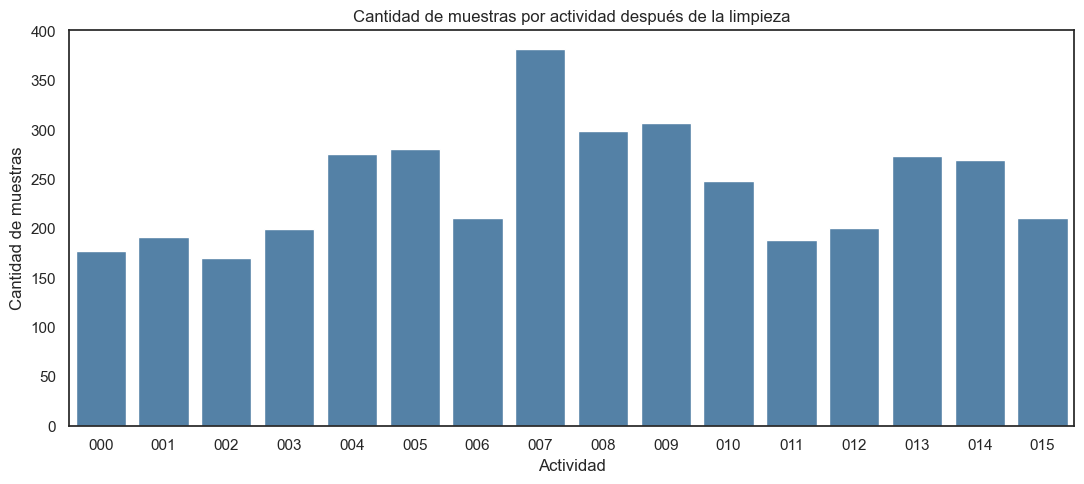

In [12]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=distribucion_limpia,
    x="actividad",
    y="cantidad_muestras",
    color="steelblue"
)

plt.title(
    "Cantidad de muestras por actividad después de la limpieza"
)
plt.xlabel("Actividad")
plt.ylabel("Cantidad de muestras")
plt.tight_layout()
plt.show()

### Interpretación

Después de eliminar las muestras completamente en cero y las copias adicionales, el conjunto contiene 3,890 muestras y conserva las 16 actividades. No quedaron valores faltantes, infinitos, muestras completamente vacías ni duplicados exactos.

La actividad `007` tiene la mayor cantidad, con 382 muestras (9.82%), mientras que la actividad `002` tiene la menor, con 170 muestras (4.37%). Aunque existe cierta diferencia entre clases, todas conservan suficientes muestras; por ello, la separación se realizará de manera estratificada para mantener proporciones similares en entrenamiento y prueba.

## 8. División del conjunto limpio en ventanas independientes

Cada señal limpia contiene 880 puntos temporales y 12 canales. En esta versión, las señales se dividirán directamente en cuatro ventanas consecutivas de 220 puntos sin realizar todavía una separación entre entrenamiento y prueba.

Cada ventana se tratará como una observación independiente y conservará la actividad de la señal de origen. Por lo tanto, una señal de `880 × 12` generará cuatro filas diferentes, cada una basada en una ventana de `220 × 12`.

Esta organización sigue la indicación de trabajar con ventanas independientes. La división en entrenamiento y prueba se realizará posteriormente sobre la tabla final de características.


In [13]:
# ---------------------------------------------------------
# Configuración de las ventanas
# ---------------------------------------------------------

TAMANIO_VENTANA = 220

# Verificamos que las 880 posiciones puedan dividirse en
# ventanas completas de 220 puntos.
if datos_limpios.shape[1] % TAMANIO_VENTANA != 0:
    raise ValueError(
        "La longitud de las señales no es divisible entre "
        "el tamaño de ventana."
    )

cantidad_ventanas = datos_limpios.shape[1] // TAMANIO_VENTANA

print("Tamaño de cada ventana:", TAMANIO_VENTANA)
print("Ventanas obtenidas por señal:", cantidad_ventanas)


Tamaño de cada ventana: 220
Ventanas obtenidas por señal: 4


In [14]:
# ---------------------------------------------------------
# Función para crear las ventanas independientes
# ---------------------------------------------------------

def crear_ventanas(datos, etiquetas, metadatos, tamanio_ventana=220):
    """Divide cada señal en ventanas consecutivas sin traslape."""

    ventanas = []
    etiquetas_ventanas = []
    registros_metadatos = []

    for indice_muestra in range(datos.shape[0]):
        senal = datos[indice_muestra]
        etiqueta = etiquetas[indice_muestra]
        metadato = metadatos.iloc[indice_muestra]

        numero_ventanas = senal.shape[0] // tamanio_ventana

        for numero_ventana in range(numero_ventanas):
            inicio = numero_ventana * tamanio_ventana
            fin = inicio + tamanio_ventana

            ventanas.append(senal[inicio:fin, :])
            etiquetas_ventanas.append(etiqueta)

            # Se conserva la procedencia únicamente para poder
            # rastrear cada ventana durante la preparación.
            registros_metadatos.append({
                "sample_id": metadato["sample_id"],
                "actividad": metadato["actividad"],
                "indice_original": metadato["indice_original"],
                "numero_ventana": numero_ventana,
                "inicio": inicio,
                "fin": fin
            })

    return (
        np.asarray(ventanas),
        np.asarray(etiquetas_ventanas),
        pd.DataFrame(registros_metadatos)
    )


(
    ventanas,
    etiquetas_ventanas,
    metadatos_ventanas
) = crear_ventanas(
    datos_limpios,
    etiquetas_limpias,
    metadatos_limpios,
    TAMANIO_VENTANA
)

print("Señales limpias originales:", datos_limpios.shape)
print("Ventanas independientes:", ventanas.shape)
print("Etiquetas de las ventanas:", etiquetas_ventanas.shape)
print("Metadatos de las ventanas:", metadatos_ventanas.shape)


Señales limpias originales: (3890, 880, 12)
Ventanas independientes: (15560, 220, 12)
Etiquetas de las ventanas: (15560,)
Metadatos de las ventanas: (15560, 6)


### Interpretación

Las 3,890 señales limpias se dividieron en cuatro ventanas de 220 puntos, generando 15,560 observaciones independientes. Cada ventana conserva los 12 canales y la etiqueta de actividad de la señal original.

Los metadatos permiten rastrear temporalmente de qué señal y posición procede cada ventana, pero no se utilizarán como características del modelo. En esta versión todavía no se realizó la separación en entrenamiento y prueba.


## 9. Extracción de características por ventana

Cada ventana conserva 220 puntos temporales y 12 canales. Para representarla como una fila tabular se calcularán diez estadísticas por canal: media, mediana, desviación estándar, mínimo, máximo, rango, percentiles 25 y 75, rango intercuartílico y RMS.

De esta manera, cada ventana de `220 × 12` se transformará en una fila con 120 características. La extracción se aplicará al conjunto completo porque la separación de los datos se realizará en una etapa posterior.


In [15]:
# ---------------------------------------------------------
# Transformador para extraer características estadísticas
# ---------------------------------------------------------

class ExtractorCaracteristicas(BaseEstimator, TransformerMixin):

    def __init__(self, nombres_canales):
        # Guardamos los nombres para crear posteriormente
        # los nombres de las columnas.
        self.nombres_canales = nombres_canales

        self.nombres_estadisticas = [
            "media",
            "mediana",
            "desviacion",
            "minimo",
            "maximo",
            "rango",
            "percentil_25",
            "percentil_75",
            "rango_intercuartil",
            "rms"
        ]

    def fit(self, datos, etiquetas=None):

        # Verificamos la estructura recibida durante el ajuste.
        if datos.ndim != 3:
            raise ValueError(
                "Los datos deben tener tres dimensiones: "
                "(muestras, puntos temporales, canales)."
            )

        if datos.shape[2] != len(self.nombres_canales):
            raise ValueError(
                f"Se esperaban {len(self.nombres_canales)} "
                f"canales, pero se recibieron {datos.shape[2]}."
            )

        # Los atributos terminados en "_" indican a
        # scikit-learn que el transformador ya fue ajustado.
        self.numero_canales_ = datos.shape[2]
        self.numero_puntos_ = datos.shape[1]

        return self

    def transform(self, datos):

        # Verificamos que la entrada tenga la estructura:
        # (muestras, puntos temporales, canales).
        if datos.ndim != 3:
            raise ValueError(
                "Los datos deben tener tres dimensiones: "
                "(muestras, puntos temporales, canales)."
            )

        if datos.shape[2] != len(self.nombres_canales):
            raise ValueError(
                f"Se esperaban {len(self.nombres_canales)} "
                f"canales, pero se recibieron {datos.shape[2]}."
            )

        # Cada operación se calcula sobre los 880 puntos,
        # conservando una medida por muestra y canal.
        media = np.mean(datos, axis=1)
        mediana = np.median(datos, axis=1)
        desviacion = np.std(datos, axis=1)

        minimo = np.min(datos, axis=1)
        maximo = np.max(datos, axis=1)
        rango = maximo - minimo

        percentil_25 = np.percentile(
            datos,
            25,
            axis=1
        )

        percentil_75 = np.percentile(
            datos,
            75,
            axis=1
        )

        rango_intercuartil = (
            percentil_75
            - percentil_25
        )

        # RMS resume la magnitud promedio de la señal.
        rms = np.sqrt(
            np.mean(
                datos ** 2,
                axis=1
            )
        )

        # Unimos horizontalmente todas las características.
        caracteristicas = np.concatenate(
            [
                media,
                mediana,
                desviacion,
                minimo,
                maximo,
                rango,
                percentil_25,
                percentil_75,
                rango_intercuartil,
                rms
            ],
            axis=1
        )

        return caracteristicas

    def get_feature_names_out(self):

        nombres = []

        # El orden debe coincidir con la concatenación
        # realizada dentro de transform().
        for estadistica in self.nombres_estadisticas:
            for canal in self.nombres_canales:
                nombres.append(
                    f"{canal}_{estadistica}"
                )

        return np.array(nombres)

In [16]:
# ---------------------------------------------------------
# Pipeline de extracción de características
# ---------------------------------------------------------

pipeline_caracteristicas = Pipeline([
    (
        "extraer_caracteristicas",
        ExtractorCaracteristicas(nombres_canales=canales)
    )
])

# Cada ventana se convierte en una fila de 120 características.
caracteristicas_ventanas = pipeline_caracteristicas.fit_transform(
    ventanas,
    etiquetas_ventanas
)

nombres_caracteristicas = (
    pipeline_caracteristicas
    .named_steps["extraer_caracteristicas"]
    .get_feature_names_out()
)

print("Ventanas originales:", ventanas.shape)
print("Tabla de características:", caracteristicas_ventanas.shape)
print("Cantidad de nombres:", len(nombres_caracteristicas))
print("\nPrimeros nombres de características:")
print(nombres_caracteristicas[:10])


Ventanas originales: (15560, 220, 12)
Tabla de características: (15560, 120)
Cantidad de nombres: 120

Primeros nombres de características:
['pitch1_media' 'yaw1_media' 'roll1_media' 'pitch2_media' 'yaw2_media'
 'roll2_media' 'f1_media' 'f2_media' 'f3_media' 'f4_media']


### Interpretación

Las 15,560 ventanas se transformaron correctamente en una tabla de 15,560 filas y 120 características. Cada fila continúa representando una sola ventana independiente, mientras que cada columna corresponde a una estadística calculada sobre uno de los 12 canales.

La etiqueta todavía se conserva por separado para comprobar la transformación y se añadirá como última columna al crear el archivo CSV.


## 10. Creación de la tabla final

Las 120 características y la etiqueta de actividad se integrarán en un único DataFrame. Cada fila representará una ventana independiente de 220 puntos y la última columna, llamada `actividad`, indicará la clase correspondiente.

Los identificadores y demás metadatos no se incorporarán a esta tabla porque no son variables predictoras. Tampoco se dividirá todavía el conjunto en entrenamiento y prueba.


In [17]:
# ---------------------------------------------------------
# Creación del DataFrame final
# ---------------------------------------------------------

datos_ventanas_df = pd.DataFrame(
    caracteristicas_ventanas,
    columns=nombres_caracteristicas
)

# La etiqueta se añade como la última columna.
datos_ventanas_df["actividad"] = etiquetas_ventanas

print("Dimensiones de la tabla final:", datos_ventanas_df.shape)
print("Cantidad de características:", len(nombres_caracteristicas))
print("Cantidad de actividades:", datos_ventanas_df["actividad"].nunique())

display(datos_ventanas_df.head())


Dimensiones de la tabla final: (15560, 121)
Cantidad de características: 120
Cantidad de actividades: 16


,pitch1_media,yaw1_media,roll1_media,pitch2_media,yaw2_media,roll2_media,f1_media,f2_media,f3_media,f4_media,...,pitch2_rms,yaw2_rms,roll2_rms,f1_rms,f2_rms,f3_rms,f4_rms,f5_rms,pitch3_rms,actividad
0,3.270629,3.226502,2.783614,2.472964,-171.088117,11.592609,3.380795,1.268409,0.909886,1.807273,...,39.435511,193.222157,18.684529,34.515611,8.526502,7.311840,5.723513,4.902443,75.582338,000
1,0.788084,-4.481529,1.747486,1.312301,53.493413,-3.893925,10.270795,-1.743409,-1.847386,-1.472273,...,41.204617,63.890171,10.810522,34.364253,9.372877,7.392927,4.996178,2.608613,79.615032,000
2,-1.475876,0.801498,-0.998842,-1.797005,61.377763,-4.048742,-7.682386,0.093409,0.094886,0.194545,...,46.129425,70.900859,11.280858,18.721137,8.183731,6.890550,5.050107,2.736483,82.035168,000
3,-2.582838,0.453528,-3.532258,-1.988260,56.216942,-3.649942,-5.969205,0.381591,0.842614,-0.529545,...,47.673730,66.851516,11.754469,26.485929,7.054135,6.040025,4.139513,2.947271,71.269307,000
4,1.864355,-3.400178,1.342095,2.638048,-0.310521,0.195843,18.805909,1.115909,0.657955,1.049773,...,42.552263,33.218385,10.832633,40.806550,8.612997,6.841425,4.995550,3.817161,83.355400,000


### Interpretación

La tabla final contiene 15,560 filas y 121 columnas. Las primeras 120 columnas corresponden a las características estadísticas y la última columna contiene la etiqueta de una de las 16 actividades.

Cada fila representa una ventana independiente. En esta etapa no existen columnas de entrenamiento o prueba y tampoco se incluyeron metadatos como `sample_id` o `numero_ventana` dentro de las variables del modelo.


## 11. Guardado del conjunto de ventanas

La tabla completa se guardará como `datos_ventanas.csv` dentro de la carpeta `datos_modelo`. El archivo conservará una fila por ventana, las 120 características y la etiqueta como última columna.

Este archivo será el punto de partida para realizar posteriormente la separación de entrenamiento y prueba y el modelado.


In [18]:
# ---------------------------------------------------------
# Guardado del único conjunto preparado
# ---------------------------------------------------------

RUTA_DATOS_MODELO = Path("../datos_modelo")
RUTA_DATOS_MODELO.mkdir(parents=True, exist_ok=True)

RUTA_CSV = RUTA_DATOS_MODELO / "datos_ventanas.csv"

datos_ventanas_df.to_csv(
    RUTA_CSV,
    index=False
)

# Volvemos a cargar el archivo para comprobar su estructura.
datos_verificados = pd.read_csv(
    RUTA_CSV,
    dtype={"actividad": str}
)

if datos_verificados.shape != datos_ventanas_df.shape:
    raise ValueError("El CSV guardado no conserva las dimensiones esperadas.")

print("Archivo guardado en:", RUTA_CSV.resolve())
print("Dimensiones verificadas:", datos_verificados.shape)
print("Etiqueta ubicada al final:", datos_verificados.columns[-1])


Archivo guardado en: /Users/emilianoguzmanibarrola/Documents/Visual Code/TC3009C/Reto 1/Concentracion_Reto/datos_modelo/datos_ventanas.csv
Dimensiones verificadas: (15560, 121)
Etiqueta ubicada al final: actividad


### Interpretación

El conjunto completo de ventanas se guardó correctamente en un solo archivo CSV. El archivo contiene 15,560 observaciones independientes, 120 características y la etiqueta `actividad` como última columna.

La tabla aún no está separada en entrenamiento y prueba. Esa división deberá efectuarse antes de ajustar los modelos de clasificación.
